## step-1:Looad the dataset

In [5]:
import pandas as pd

In [6]:
#load the dataset
data = pd.read_csv("sample dataset.csv")
print(data)

     Transaction_ID        Date           State      City    Category  \
0                 1  2026-08-01  Andhra Pradesh  Tirupati  Vegetables   
1                 2  2026-08-02  Andhra Pradesh  Tirupati       Dairy   
2                 3  2026-08-03  Andhra Pradesh   Nellore      Fruits   
3                 4  2026-08-04  Andhra Pradesh  Chittoor   Groceries   
4                 5  2026-08-05  Andhra Pradesh  Tirupati   Beverages   
..              ...         ...             ...       ...         ...   
99              100  2026-11-08  Andhra Pradesh  Chittoor   Beverages   
100               5  2026-08-05  Andhra Pradesh  Tirupati   Beverages   
101              20  2026-08-20  Andhra Pradesh  Chittoor   Beverages   
102              50  2026-09-19  Andhra Pradesh   Nellore   Beverages   
103              80  2026-10-19  Andhra Pradesh  Chittoor   Beverages   

            Product  Quantity  Unit_Price_INR  Total_Sales_INR Customer_Type  \
0            Potato     120.0            42

## step-2:identifying missing values

In [7]:
print("\nMissing Values Count:")
print(data.isnull().sum())


Missing Values Count:
Transaction_ID     0
Date               0
State              0
City               2
Category           1
Product            1
Quantity           1
Unit_Price_INR     2
Total_Sales_INR    1
Customer_Type      1
Payment_Method     1
dtype: int64


## step-3:Handle Missing Values

In [10]:
data['City'] = data['City'].fillna(data['City'].mode()[0])
data['Category'] = data['Category'].fillna(data['Category'].mode()[0])
data['Product'] = data['Product'].fillna(data['Product'].mode()[0])
data['Customer_Type'] = data['Customer_Type'].fillna(data['Customer_Type'].mode()[0])
data['Payment_Method'] = data['Payment_Method'].fillna(data['Payment_Method'].mode()[0])
data['Quantity'] = data['Quantity'].fillna(data['Quantity'].median())
data['Unit_Price_INR'] = data['Unit_Price_INR'].fillna(data['Unit_Price_INR'].median())
data['Total_Sales_INR'] = data['Total_Sales_INR'].fillna(data['Total_Sales_INR'].median())
data = data.dropna(subset=['Date'])
print(data)

     Transaction_ID        Date           State      City    Category  \
0                 1  2026-08-01  Andhra Pradesh  Tirupati  Vegetables   
1                 2  2026-08-02  Andhra Pradesh  Tirupati       Dairy   
2                 3  2026-08-03  Andhra Pradesh   Nellore      Fruits   
3                 4  2026-08-04  Andhra Pradesh  Chittoor   Groceries   
4                 5  2026-08-05  Andhra Pradesh  Tirupati   Beverages   
..              ...         ...             ...       ...         ...   
99              100  2026-11-08  Andhra Pradesh  Chittoor   Beverages   
100               5  2026-08-05  Andhra Pradesh  Tirupati   Beverages   
101              20  2026-08-20  Andhra Pradesh  Chittoor   Beverages   
102              50  2026-09-19  Andhra Pradesh   Nellore   Beverages   
103              80  2026-10-19  Andhra Pradesh  Chittoor   Beverages   

            Product  Quantity  Unit_Price_INR  Total_Sales_INR Customer_Type  \
0            Potato     120.0            42

## Step-4: check and remove duplicates

In [11]:
data = data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
data = data.apply(lambda x: x.str.lower() if x.dtype == "object" else x)
print(data)

     Transaction_ID        Date           State      City    Category  \
0                 1  2026-08-01  andhra pradesh  tirupati  vegetables   
1                 2  2026-08-02  andhra pradesh  tirupati       dairy   
2                 3  2026-08-03  andhra pradesh   nellore      fruits   
3                 4  2026-08-04  andhra pradesh  chittoor   groceries   
4                 5  2026-08-05  andhra pradesh  tirupati   beverages   
..              ...         ...             ...       ...         ...   
99              100  2026-11-08  andhra pradesh  chittoor   beverages   
100               5  2026-08-05  andhra pradesh  tirupati   beverages   
101              20  2026-08-20  andhra pradesh  chittoor   beverages   
102              50  2026-09-19  andhra pradesh   nellore   beverages   
103              80  2026-10-19  andhra pradesh  chittoor   beverages   

            Product  Quantity  Unit_Price_INR  Total_Sales_INR Customer_Type  \
0            potato     120.0            42

In [13]:
data = data.drop_duplicates(subset=['Date', 'State'])
print(data)

    Transaction_ID        Date           State      City    Category  \
0                1  2026-08-01  andhra pradesh  tirupati  vegetables   
1                2  2026-08-02  andhra pradesh  tirupati       dairy   
2                3  2026-08-03  andhra pradesh   nellore      fruits   
3                4  2026-08-04  andhra pradesh  chittoor   groceries   
4                5  2026-08-05  andhra pradesh  tirupati   beverages   
..             ...         ...             ...       ...         ...   
95              96  2026-11-04  andhra pradesh  chittoor  vegetables   
96              97  2026-11-05  andhra pradesh  tirupati      fruits   
97              98  2026-11-06  andhra pradesh   nellore   groceries   
98              99  2026-11-07  andhra pradesh  tirupati       dairy   
99             100  2026-11-08  andhra pradesh  chittoor   beverages   

           Product  Quantity  Unit_Price_INR  Total_Sales_INR Customer_Type  \
0           potato     120.0            42.5           5

In [14]:
print(data.duplicated().sum())

0


## step-5:Handle outliers

In [15]:
Q1 = data['Total_Sales_INR'].quantile(0.25)
Q3 = data['Total_Sales_INR'].quantile(0.75)

IQR = Q3 - Q1


data = data[
    (data['Total_Sales_INR'] >= Q1 - 1.5 * IQR) &
    (data['Total_Sales_INR'] <= Q3 + 1.5 * IQR)
]

print(data)

    Transaction_ID        Date           State      City    Category  \
0                1  2026-08-01  andhra pradesh  tirupati  vegetables   
1                2  2026-08-02  andhra pradesh  tirupati       dairy   
2                3  2026-08-03  andhra pradesh   nellore      fruits   
3                4  2026-08-04  andhra pradesh  chittoor   groceries   
4                5  2026-08-05  andhra pradesh  tirupati   beverages   
..             ...         ...             ...       ...         ...   
95              96  2026-11-04  andhra pradesh  chittoor  vegetables   
96              97  2026-11-05  andhra pradesh  tirupati      fruits   
97              98  2026-11-06  andhra pradesh   nellore   groceries   
98              99  2026-11-07  andhra pradesh  tirupati       dairy   
99             100  2026-11-08  andhra pradesh  chittoor   beverages   

           Product  Quantity  Unit_Price_INR  Total_Sales_INR Customer_Type  \
0           potato     120.0            42.5           5

## step-6: convert data types

In [16]:
data['Date'] = pd.to_datetime(data['Date'])
print(data)

    Transaction_ID       Date           State      City    Category  \
0                1 2026-08-01  andhra pradesh  tirupati  vegetables   
1                2 2026-08-02  andhra pradesh  tirupati       dairy   
2                3 2026-08-03  andhra pradesh   nellore      fruits   
3                4 2026-08-04  andhra pradesh  chittoor   groceries   
4                5 2026-08-05  andhra pradesh  tirupati   beverages   
..             ...        ...             ...       ...         ...   
95              96 2026-11-04  andhra pradesh  chittoor  vegetables   
96              97 2026-11-05  andhra pradesh  tirupati      fruits   
97              98 2026-11-06  andhra pradesh   nellore   groceries   
98              99 2026-11-07  andhra pradesh  tirupati       dairy   
99             100 2026-11-08  andhra pradesh  chittoor   beverages   

           Product  Quantity  Unit_Price_INR  Total_Sales_INR Customer_Type  \
0           potato     120.0            42.5           5100.0       

## step-7: Encode Categorical variables

In [18]:
#one-hot encode the "Category" column
data = pd.get_dummies(data, columns=['Category'], drop_first=True)
#convert only the one-hot encoded columns to integers
binary_columns = [col for col in data.columns if col.startswith('Category_')]
data[binary_columns] = data[binary_columns].astype(int)
print(data)

    Transaction_ID       Date           State      City         Product  \
0                1 2026-08-01  andhra pradesh  tirupati          potato   
1                2 2026-08-02  andhra pradesh  tirupati          paneer   
2                3 2026-08-03  andhra pradesh   nellore          banana   
3                4 2026-08-04  andhra pradesh  chittoor            rice   
4                5 2026-08-05  andhra pradesh  tirupati           juice   
..             ...        ...             ...       ...             ...   
95              96 2026-11-04  andhra pradesh  chittoor      sweet corn   
96              97 2026-11-05  andhra pradesh  tirupati          chikoo   
97              98 2026-11-06  andhra pradesh   nellore       moong dal   
98              99 2026-11-07  andhra pradesh  tirupati           lassi   
99             100 2026-11-08  andhra pradesh  chittoor  tender coconut   

    Quantity  Unit_Price_INR  Total_Sales_INR Customer_Type Payment_Method  \
0      120.0         

## step-8:save the dataset

In [19]:
data.to_csv("Cleaned_data.csv", index=False)

## visualization

In [21]:
import matplotlib.pyplot as plt
#laod my dataset
data = pd.read_csv("Cleaned_data.csv")
#display the first few rows of the dataset
print(data.head())

   Transaction_ID        Date           State      City Product  Quantity  \
0               1  2026-08-01  andhra pradesh  tirupati  potato     120.0   
1               2  2026-08-02  andhra pradesh  tirupati  paneer      35.0   
2               3  2026-08-03  andhra pradesh   nellore  banana     180.0   
3               4  2026-08-04  andhra pradesh  chittoor    rice      75.0   
4               5  2026-08-05  andhra pradesh  tirupati   juice      95.0   

   Unit_Price_INR  Total_Sales_INR Customer_Type Payment_Method  \
0            42.5           5100.0        retail            upi   
1           280.0           9800.0        retail           cash   
2            38.0           6840.0        retail            upi   
3            62.0           4650.0     wholesale  bank transfer   
4            55.0           5225.0        retail            upi   

   Category_dairy  Category_fruits  Category_groceries  Category_snacks  \
0               0                0                   0     

## Bar Chart for Product Categories

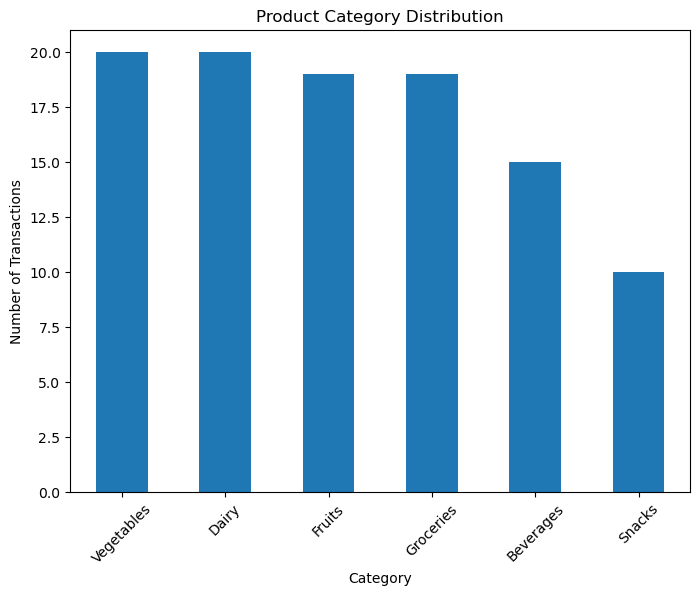

In [23]:
data = pd.read_csv("sample dataset.csv")

data.columns = data.columns.str.strip()

category_counts = data['Category'].value_counts()

category_counts.plot(kind='bar', figsize=(8, 6))

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

## Histogram for Total Sales

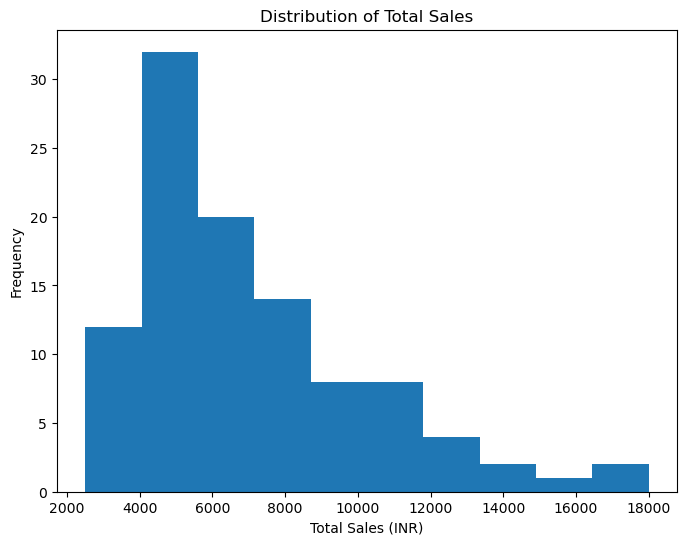

In [24]:
import matplotlib.pyplot as plt

# Histogram for Total Sales
data['Total_Sales_INR'].plot(kind='hist', bins=10, figsize=(8, 6))

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales (INR)")
plt.ylabel("Frequency")

plt.show()

## Line plot of Quantity vs Total Sales:

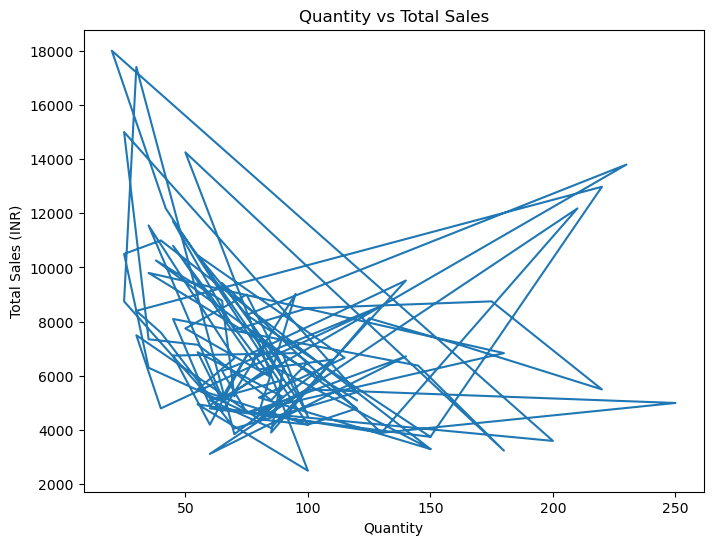

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(data['Quantity'], data['Total_Sales_INR'])

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales (INR)")

plt.show()

## scatter plot Quantity vs Total Sales

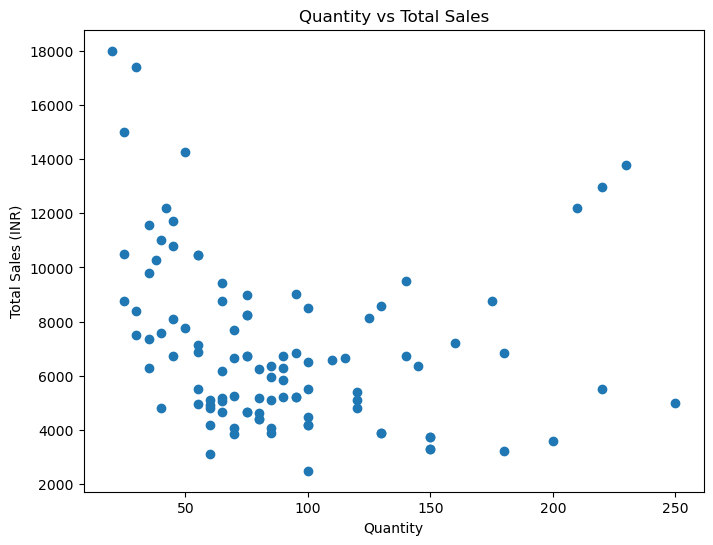

In [26]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(data['Quantity'], data['Total_Sales_INR'])

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales (INR)")

plt.show()